# ProveTok Stage0-4 Output Analysis (Colab)

这个 notebook 用于分析 `run_mini_experiment.py` 产出的结果（450/450 或 smoke）。

输入目录需要包含：
- `summary.csv`
- `ctrate_case_summary.csv`
- `radgenome_case_summary.csv`
- `run_meta.json`
- `cases/*/*/trace.jsonl`


In [1]:
# Colab dependencies
!pip -q install pandas numpy matplotlib

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 修改成你的输出目录
OUT_DIR = Path('/content/drive/MyDrive/deliverables_5090_full450_required_20260304_025431')
assert OUT_DIR.exists(), f'Not found: {OUT_DIR}'
print('OUT_DIR =', OUT_DIR)

OUT_DIR = /content/drive/MyDrive/deliverables_5090_full450_required_20260304_025431


## 1) 先做结构验收

In [4]:
# 如果仓库不在当前会话，先 clone 一份
%cd /content
!test -d ProveTok_ACM || git clone https://github.com/Ricardo-ChenTY/ProveTok_ACM.git
%cd /content/ProveTok_ACM

!python validate_stage0_4_outputs.py \
  --out_dir "$OUT_DIR" \
  --datasets ctrate,radgenome \
  --expected_cases_map ctrate=450,radgenome=450 \
  --save_report "$OUT_DIR/validation_report.json"

流式输出内容被截断，只能显示最后 5000 行内容。

[FAIL] ctrate/train_13007_a_2
  - ERROR: missing file: tokens.npy
  - ERROR: missing file: tokens.pt
  - ERROR: missing file: tokens.json
  - ERROR: missing file: bank_meta.json

[FAIL] ctrate/train_13023_a_2
  - ERROR: missing file: tokens.npy
  - ERROR: missing file: tokens.pt
  - ERROR: missing file: tokens.json
  - ERROR: missing file: bank_meta.json

[FAIL] ctrate/train_13032_a_2
  - ERROR: missing file: tokens.npy
  - ERROR: missing file: tokens.pt
  - ERROR: missing file: tokens.json
  - ERROR: missing file: bank_meta.json

[FAIL] ctrate/train_13040_a_1
  - ERROR: missing file: tokens.npy
  - ERROR: missing file: tokens.pt
  - ERROR: missing file: tokens.json
  - ERROR: missing file: bank_meta.json

[FAIL] ctrate/train_13099_d_1
  - ERROR: missing file: tokens.npy
  - ERROR: missing file: tokens.pt
  - ERROR: missing file: tokens.json
  - ERROR: missing file: bank_meta.json

[FAIL] ctrate/train_13099_d_2
  - ERROR: missing file: tokens.npy
  - ERROR: 

In [5]:
run_meta_path = OUT_DIR / 'run_meta.json'
assert run_meta_path.exists(), 'run_meta.json missing'
run_meta = json.loads(run_meta_path.read_text(encoding='utf-8'))

print('cp_strict =', run_meta.get('cp_strict'))
print('text_encoder =', run_meta.get('text_encoder'))
print('ctrate selected/processed =', run_meta['ctrate']['selected_rows'], run_meta['ctrate']['processed_rows'])
print('radgenome selected/processed =', run_meta['radgenome']['selected_rows'], run_meta['radgenome']['processed_rows'])

cp_strict = True
text_encoder = semantic
ctrate selected/processed = 450 450
radgenome selected/processed = 450 450


## 2) 全局汇总统计

In [6]:
summary = pd.read_csv(OUT_DIR / 'summary.csv')
display(summary.head())

agg = summary.groupby('dataset', as_index=False).agg(
    cases=('case_id', 'count'),
    avg_tokens=('n_tokens', 'mean'),
    avg_sentences=('n_sentences', 'mean'),
    avg_violations=('n_violations', 'mean'),
    total_violations=('n_violations', 'sum'),
)
display(agg)

,dataset,case_id,n_tokens,n_sentences,n_violations,trace_jsonl
0,ctrate,train_10004_a_2,64,8,9,outputs_stage0_4_5090_full450_cp_strict\cases\...
1,ctrate,train_10047_a_1,64,8,6,outputs_stage0_4_5090_full450_cp_strict\cases\...
2,ctrate,train_10077_a_1,64,8,8,outputs_stage0_4_5090_full450_cp_strict\cases\...
3,ctrate,train_10110_a_1,64,8,10,outputs_stage0_4_5090_full450_cp_strict\cases\...
4,ctrate,train_10203_a_1,64,8,8,outputs_stage0_4_5090_full450_cp_strict\cases\...


,dataset,cases,avg_tokens,avg_sentences,avg_violations,total_violations
0,ctrate,450,64.0,7.991111,6.933333,3120
1,radgenome,450,64.0,7.980000,7.431111,3344


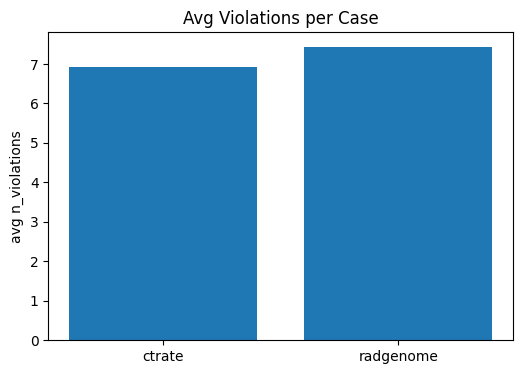

In [7]:
plt.figure(figsize=(6, 4))
plt.bar(agg['dataset'], agg['avg_violations'])
plt.title('Avg Violations per Case')
plt.ylabel('avg n_violations')
plt.show()

## 3) 解析 trace.jsonl（规则/句子级）

In [8]:
from collections import Counter

trace_files = sorted((OUT_DIR / 'cases').glob('*/*/trace.jsonl'))
print('trace files:', len(trace_files))

rows = []
rule_counter = Counter()

for tf in trace_files:
    dataset = tf.parts[-3]
    case_id = tf.parts[-2]
    with tf.open('r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            obj = json.loads(line)
            if 'sentence_text' not in obj:
                continue
            vios = obj.get('violations', []) or []
            rule_ids = [v.get('rule_id', 'UNKNOWN') for v in vios if isinstance(v, dict)]
            for rid in rule_ids:
                rule_counter[rid] += 1
            rows.append({
                'dataset': dataset,
                'case_id': case_id,
                'sentence_text': obj.get('sentence_text', ''),
                'n_topk': len(obj.get('topk_token_ids', []) or []),
                'n_violations': len(vios),
                'has_violation': int(len(vios) > 0),
                'rule_ids': '|'.join(rule_ids),
            })

sent_df = pd.DataFrame(rows)
display(sent_df.head())
print('sentence rows:', len(sent_df))

trace files: 900


,dataset,case_id,sentence_text,n_topk,n_violations,has_violation,rule_ids
0,ctrate,train_10004_a_2,"In the upper inner part of the left breast, an...",8,3,1,R2_ANATOMY|R4_SIZE|R5_NEGATION
1,ctrate,train_10004_a_2,"Trachea, both main bronchi are open",8,1,1,R2_ANATOMY
2,ctrate,train_10004_a_2,"Mediastinal main vascular structures, heart co...",8,1,1,R1_LATERALITY
3,ctrate,train_10004_a_2,Thoracic aorta diameter is normal,8,1,1,R1_LATERALITY
4,ctrate,train_10004_a_2,Calcific atheroma plaques are seen in the coro...,8,1,1,R1_LATERALITY


sentence rows: 7187


,rule_id,count
0,R2_ANATOMY,2651
1,R1_LATERALITY,2009
2,R5_NEGATION,925
3,R4_SIZE,879


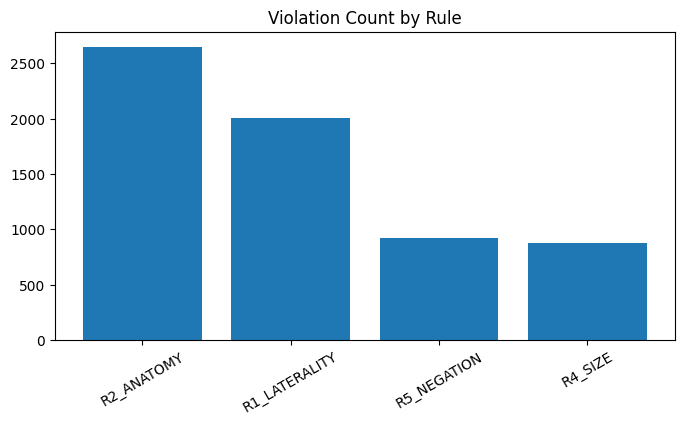

In [9]:
rule_df = pd.DataFrame([
    {'rule_id': k, 'count': v} for k, v in sorted(rule_counter.items(), key=lambda x: -x[1])
])
display(rule_df)

if not rule_df.empty:
    plt.figure(figsize=(8, 4))
    plt.bar(rule_df['rule_id'], rule_df['count'])
    plt.title('Violation Count by Rule')
    plt.xticks(rotation=30)
    plt.show()

In [10]:
sent_agg = sent_df.groupby('dataset', as_index=False).agg(
    sentences=('sentence_text', 'count'),
    violation_sentences=('has_violation', 'sum'),
)
sent_agg['violation_sentence_rate'] = sent_agg['violation_sentences'] / sent_agg['sentences'].clip(lower=1)
display(sent_agg)

,dataset,sentences,violation_sentences,violation_sentence_rate
0,ctrate,3596,2630,0.731368
1,radgenome,3591,2555,0.711501


In [11]:
case_abn = sent_df.groupby(['dataset', 'case_id'], as_index=False).agg(
    n_sentences=('sentence_text', 'count'),
    n_violation_sentences=('has_violation', 'sum'),
)
case_abn['violation_ratio'] = case_abn['n_violation_sentences'] / case_abn['n_sentences'].clip(lower=1)
case_abn = case_abn.sort_values(['violation_ratio', 'n_violation_sentences'], ascending=[False, False])
display(case_abn.head(30))

,dataset,case_id,n_sentences,n_violation_sentences,violation_ratio
79,ctrate,train_13479_b_2,8,8,1.0
95,ctrate,train_14198_b_2,8,8,1.0
96,ctrate,train_1423_a_2,8,8,1.0
131,ctrate,train_15672_a_1,8,8,1.0
193,ctrate,train_18465_a_1,8,8,1.0
201,ctrate,train_18856_a_1,8,8,1.0
207,ctrate,train_19235_a_1,8,8,1.0
215,ctrate,train_19435_a_1,8,8,1.0
220,ctrate,train_19588_b_1,8,8,1.0
222,ctrate,train_19703_a_2,8,8,1.0


## 4) 导出分析结果（给组会/写作）

In [12]:
analysis_dir = OUT_DIR / 'analysis_exports'
analysis_dir.mkdir(parents=True, exist_ok=True)

agg.to_csv(analysis_dir / 'dataset_aggregate.csv', index=False)
sent_agg.to_csv(analysis_dir / 'sentence_violation_rate.csv', index=False)
rule_df.to_csv(analysis_dir / 'rule_violation_count.csv', index=False)
case_abn.to_csv(analysis_dir / 'abnormal_cases_ranked.csv', index=False)

print('saved to:', analysis_dir)

saved to: /content/drive/MyDrive/deliverables_5090_full450_required_20260304_025431/analysis_exports
